# Kaggle Space Titanic prediction quest  by 김민수

#Summary

- null 값이 많은 데이터 셋이었기에 각각의 null 값들 어떤 방식으로 처리할지 고민이 되었음. 
  중요도가 낮은 값은 최고빈도 값으로, 중요도가 있다고 추정한 값은 unknown 이란 별도 값을 추가하였음.

- Cabin 데이터가 선박 내 탑승객의 위치 정보을 나타내기에 이 값을 Cabin 1~3 값으로 분할하여 활용하였음.
  특히 Cabin3 값이 타겟값과의 상관관계 지수가 높게 나타났음. 

- Shopping mall, Spa 와 같은 어메니티 지출액은 expense_sum 이라는 항목에 합계를 구하여 넣어두고,
  일부 중복성이 높다고 판단된 컬럼(Shopping mall 등)을 삭제하였음. 

- Age는 연령에 따라 생존율이 다르게 나타나는 다소 복잡한 패턴이 관측되었기에 (아래 내용 중 그래프에서 확인 가능)
  생존율이 높았던 어린이 그룹과 생존율이 특히 낮았던 20대 그룹 등을 몇개의 Age group으로 나누어 int값 적용하였음.

- 학습 모델은 4개 모델을 앙상블 형태로 결합하여 Voting 하여 최적값을 도출하였음 (참고 링크1 내용에 기반)

- 학습모델과 전처리 기본 작업 이후에는 피처값들의 미세조정 및 학습모델 파라미터 값 조정을 통해 최적화 작업 진행.

- 여러번 최적화 시도 하였으나 결국 80.5% 목표치는 달성하지 못하였음.

#회고 

- 지난번 퀘스트(집값 예측)의 경험에 비추어, 모델의 최적화보다 데이터 전처리가 더 많은 영향을 끼친다고 판단하여
  데이터 전처리에 더 많은 시간을 투입하였음. 

- 학습모델에 대해서는 개념적으로는 대략 이해했지만, 세부 세팅을 어떻게 해야 더 나은 값을 얻을수 있는지에 대해서는 
  배우거나 혹은 찾지 못하여 우선 참고 대상의 코드를 대부분 그대로 적용하였고, 제미나이의 조언에 따라 튜닝하였음.

- 학습모델에 대해 더 많은 내용들을 배울수 있었다면 이번 퀘스트의 결과값을 얻는데 좀 더 수월했을 것으로 추측함.

- 동시에 학습모델 최적화를 위해 GridSearch의 파라미터 값을 반복 입력하는 작업에 상당한 시간이 소요되어 피로도를 높였음.

1. 기본 세팅 : 라이브러리 호출 및 데이터 로드

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/space_titanic')

train_data_path = os.path.join(data_dir, 'train.csv')
test_data_path = os.path.join(data_dir, 'test.csv')  

2. Train 데이터 null 여부 체크

<Axes: >

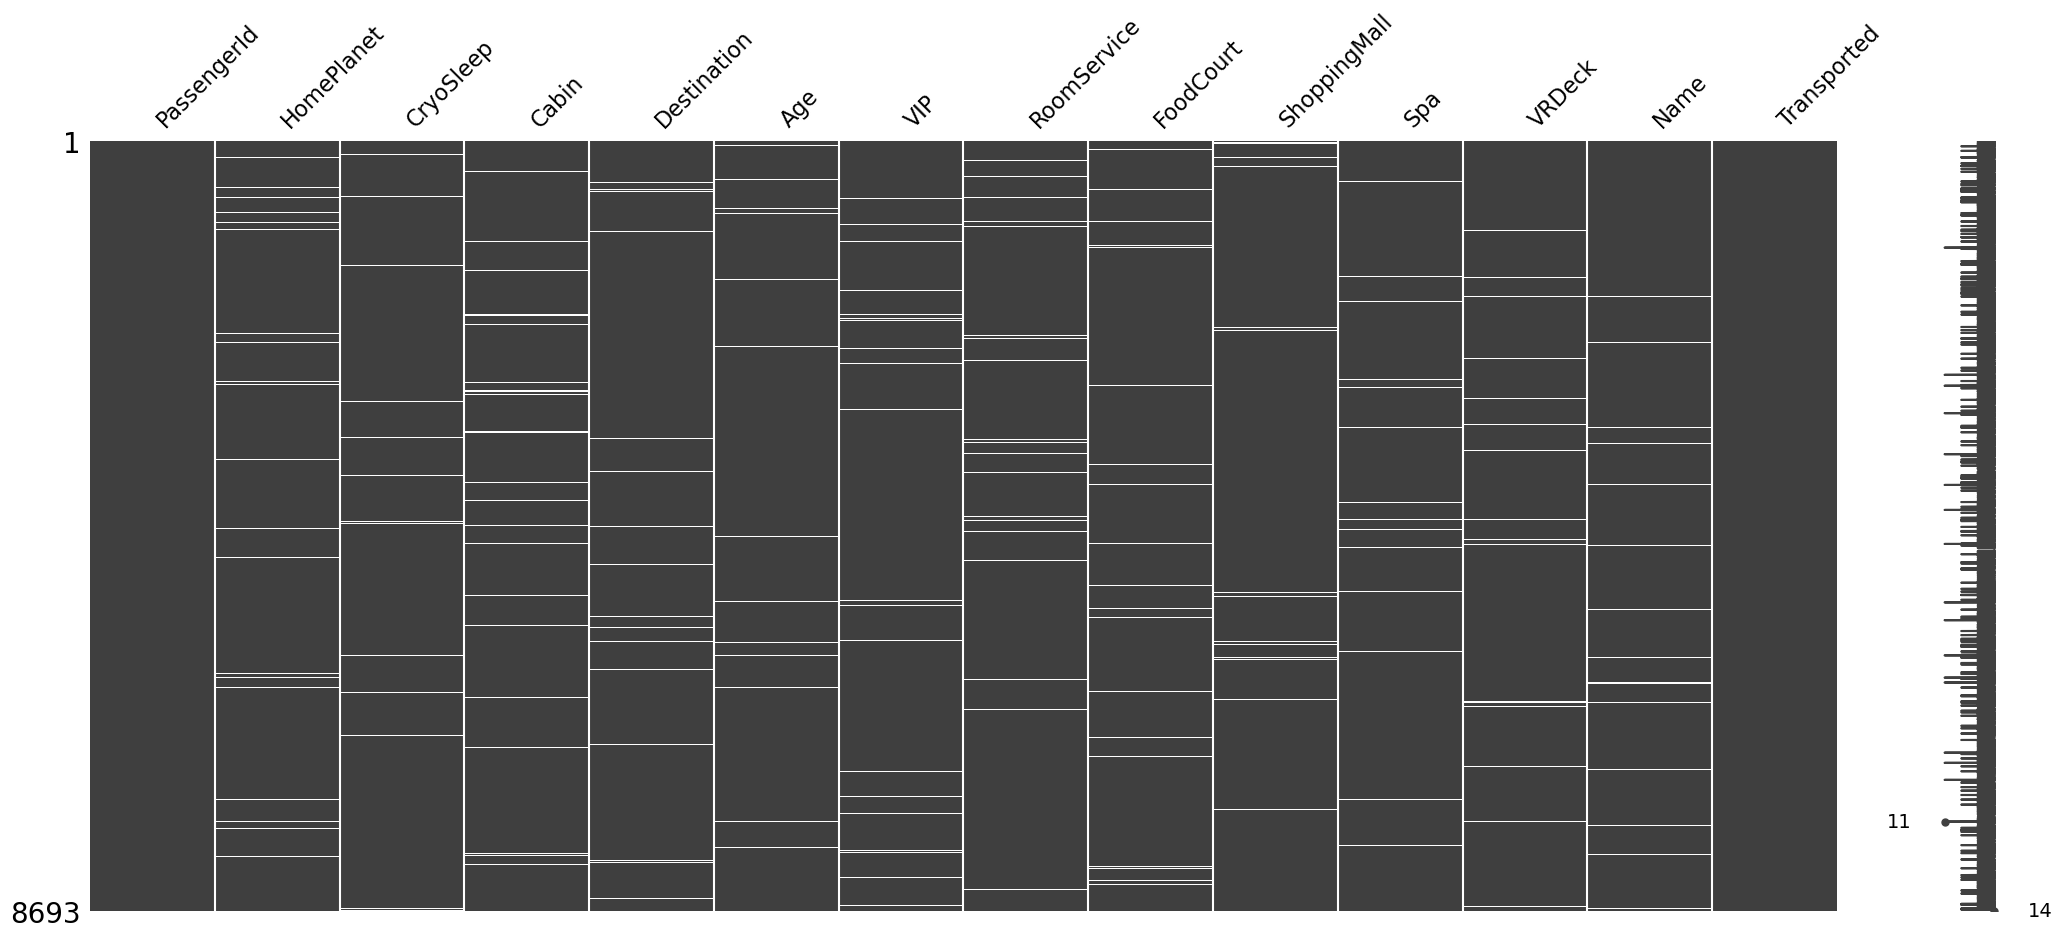

In [2]:
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)
msno.matrix(train)

In [86]:
print(train.isnull().sum())
test.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

3. EDA (데이터 분석) 및 시각화 

In [3]:
train['Transported'].value_counts()  #전체 승객 중 생존자 수

Transported
True     4378
False    4315
Name: count, dtype: int64

In [41]:
train[['Transported', 'VIP']].groupby(['Transported'], as_index=True).sum()

,VIP
Transported,
False,123
True,76


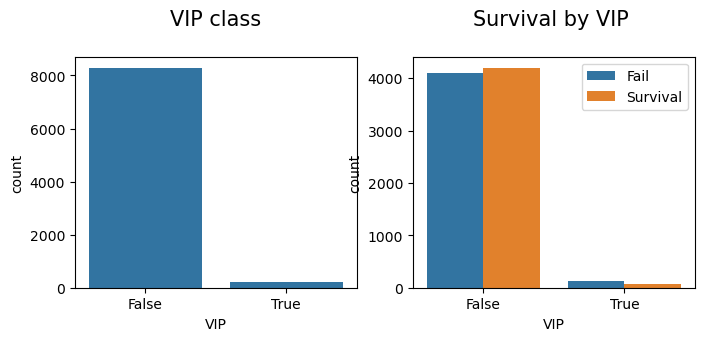

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].set_title("VIP class\n", size=15)
sns.countplot(x="VIP", data=train, ax=axes[0])

axes[1].set_title("Survival by VIP \n", size=15)
sns.countplot(x="VIP", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Fail', 'Survival'])

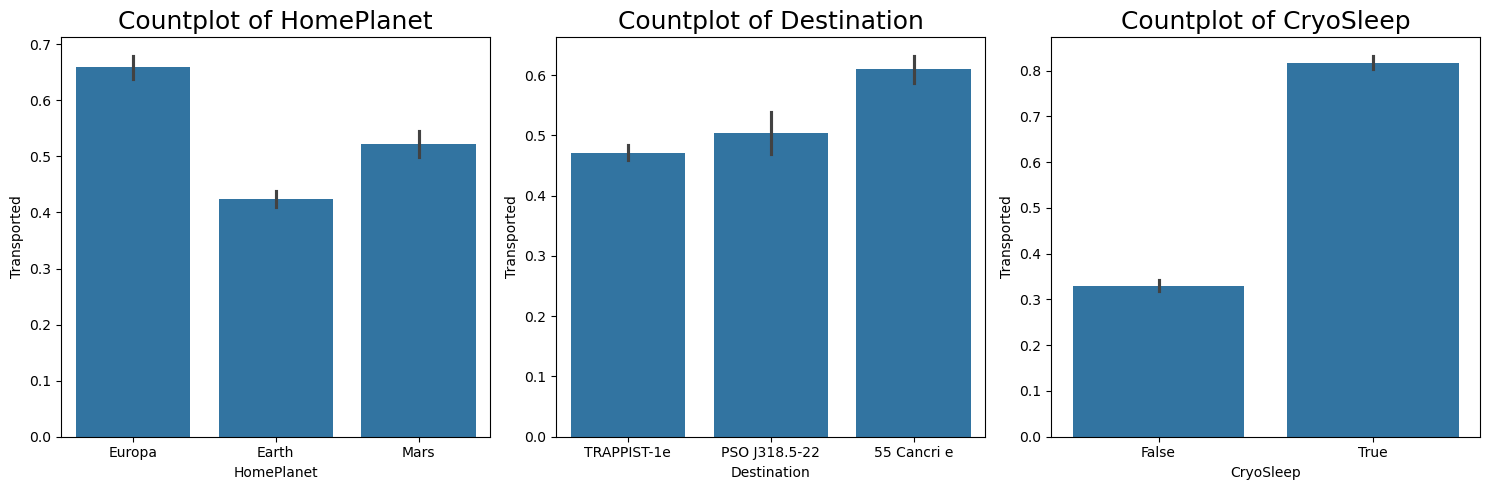

In [50]:
#피처별 생존율 그래프
fig, axes = plt.subplots(1,3, figsize=(15,5))     
cols = ['HomePlanet', 'Destination', 'CryoSleep']

for ax, col in zip(axes.flatten(), cols):
    sns.barplot(x=col, y='Transported', data=train, ax=ax)
    ax.set_title(f'Countplot of {col}', fontdict={'fontsize':18})
plt.tight_layout()
plt.show()

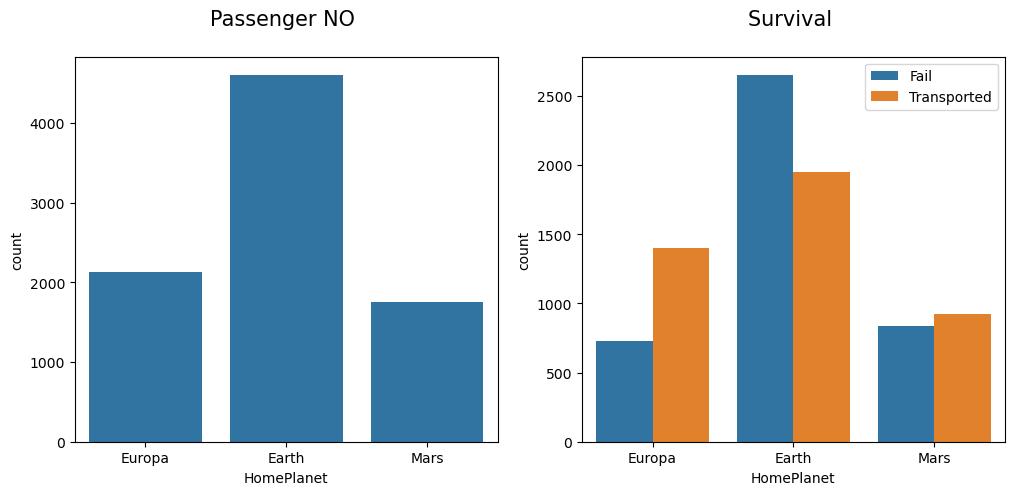

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Passenger NO \n", size=15)
sns.countplot(data=train, x='HomePlanet', ax=axes[0])

axes[1].set_title("Survival \n", size=15)
sns.countplot(x="HomePlanet", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Fail', 'Transported'])

Text(0.5, 1.0, 'Survival by HomePlanet')

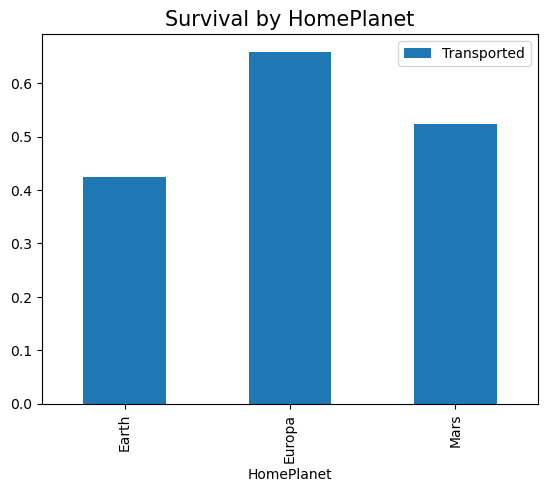

In [62]:
# HomePlanet별 생존률
sur = train[['HomePlanet', 'Transported']].groupby(['HomePlanet']).mean().plot.bar()
sur.set_title('Survival by HomePlanet', size=15)

<Axes: xlabel='Age', ylabel='Density'>

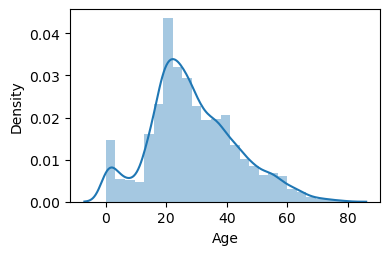

In [77]:
plt.figure(figsize=(4, 2.5))
sns.distplot(train['Age'], bins=25)

<Axes: xlabel='Age', ylabel='Density'>

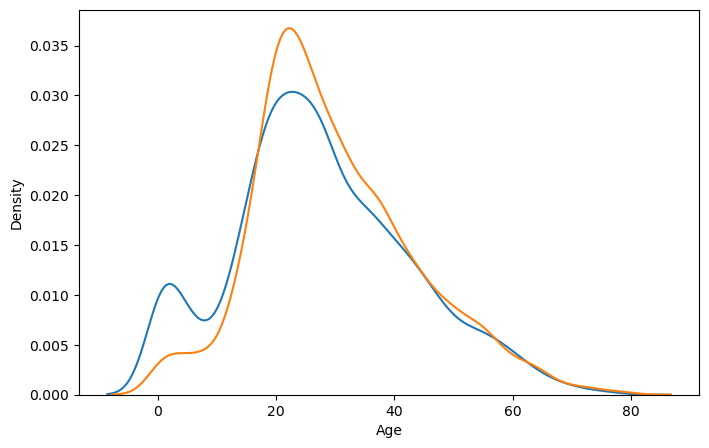

In [78]:
sur = train[train['Transported'] == 1]
dead = train[train['Transported'] == 0]

plt.figure(figsize=(8, 5))
sns.distplot(sur['Age'], bins=25, hist=False)
sns.distplot(dead['Age'], bins=25, hist=False)

4. 데이터 전처리

   - Null 값 채우기: 0, 최대빈도값, 혹은 별도의 값 설정
   - 피처 추가: Active_No_Spend, Route, Cabin1~3 정보 추가
   - 카테고리 타입으로 데이터타입 변경: HomePlanet, Destination, Cabin1, Cabin3, Route 등

In [3]:
train_len = len(train)
data = pd.concat([train, test]).reset_index(drop=True)   # 전체 합치기
test_id = data['PassengerId'][train_len:].reset_index(drop=True)  # test의 passenger id 저장

#지출액 데이터 null data 처리
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data[expense_cols] = data[expense_cols].fillna(0)
data['expense_sum'] = data[expense_cols].sum(axis=1).astype(int)
data['Active_No_Spend'] = ((data['CryoSleep'] == 0) & (data['expense_sum'] == 0)).astype(int)
data['Active_No_Spend'] = data['Active_No_Spend'].astype('category')

#T/F 데이터 null data 처리
TF_cols = ['CryoSleep', 'VIP']
data[TF_cols] = data[TF_cols].fillna(False)
data[TF_cols] = data[TF_cols].replace({True: 1, False: 0})
data['CryoSleep'] = data['CryoSleep'].astype('category')
# data['VIP'] = data['VIP'].astype('category')

#출발지, 목적지 데이터 전처리
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['HomePlanet'] = data['HomePlanet'].fillna('unknown')
data['HomePlanet'] = le.fit_transform(data['HomePlanet'].astype('category'))
data['HomePlanet'] = data['HomePlanet'].astype('category')

mode_destination = data['Destination'].mode()[0] 
data['Destination'] = data['Destination'].fillna(mode_destination)
data['Destination'] = le.fit_transform(data['Destination'].astype('category'))
data['Destination'] = data['Destination'].astype('category')

#Age 값 처리
mode_age = data['Age'].mode()[0]
data['Age'] = data['Age'].fillna(mode_age)
data.loc[ data['Age'] <= 8, 'Age'] = 0
data.loc[(data['Age'] > 8) & (data['Age'] <= 18), 'Age'] = 1
data.loc[(data['Age'] > 18) & (data['Age'] <= 42), 'Age'] = 2
# data.loc[(data['Age'] > 32) & (data['Age'] <= 42), 'Age'] = 3
data.loc[(data['Age'] > 42) & (data['Age'] <= 57), 'Age'] = 3
data.loc[ data['Age'] > 57, 'Age'] = 4
data['Age'] = data['Age'].astype(int)

#Cabin 위치 처리
data['Cabin'] = data['Cabin'].fillna('un/50/un')
data['Cabin1'] = data['Cabin'].apply(lambda x: x.split('/')[0])
data['Cabin2'] = data['Cabin'].apply(lambda x: x.split('/')[1])
data['Cabin3'] = data['Cabin'].apply(lambda x: x.split('/')[2])
cab_cols = ['Cabin1', 'Cabin2', 'Cabin3']
data['Cabin1'] = le.fit_transform(data['Cabin1'].astype('category'))
data['Cabin2'] = data['Cabin2'].astype(int)
# data['Cabin2'] = le.fit_transform(data['Cabin2'].astype('category'))
data['Cabin3'] = le.fit_transform(data['Cabin3'].astype('category'))
data['Cabin1'] = data['Cabin1'].astype('category')
data['Cabin3'] = data['Cabin3'].astype('category')

#PassengerID 중 끝자리 가져오기: 혼자 or 일행(가족) 유무
data['passenger_grp'] = data['PassengerId'].apply(lambda x: x.split('_')[1])
data['passenger_grp'] = data['passenger_grp'].astype(int)

#출발지-도착지를 연결하는 Route 피처 추가
data['Route'] = data['HomePlanet'].astype(str) + '_' + data['Destination'].astype(str)
data['Route'] = le.fit_transform(data['Route'])
data['Route'] = data['Route'].astype('category')

In [55]:
print(data['Active_No_Spend'].head(200))
data['Route'].dtype

0      1
1      0
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    0
199    0
Name: Active_No_Spend, Length: 200, dtype: category
Categories (2, int64): [0, 1]


CategoricalDtype(categories=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], ordered=False, categories_dtype=int64)

5. 불필요한 정보 칼럼 삭제 및 train/test 데이터 분리

In [4]:
del data['PassengerId']
del data['Name'] 
del data['Cabin'] 
del data['Cabin2']
del data['VRDeck']
del data['ShoppingMall']
del data['Spa']
# del data['FoodCourt']

train = data.iloc[:train_len]
test  = data.iloc[train_len:]

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = train[col].astype('category').cat.codes
        test[col]  = test[col].astype('category').cat.codes

print(train.dtypes)

HomePlanet         category
CryoSleep          category
Destination        category
Age                   int64
VIP                   int64
RoomService         float64
FoodCourt           float64
Transported            int8
expense_sum           int64
Active_No_Spend    category
Cabin1             category
Cabin3             category
passenger_grp         int64
Route              category
dtype: object


6. 데이터 전처리 결과 그래프로 확인

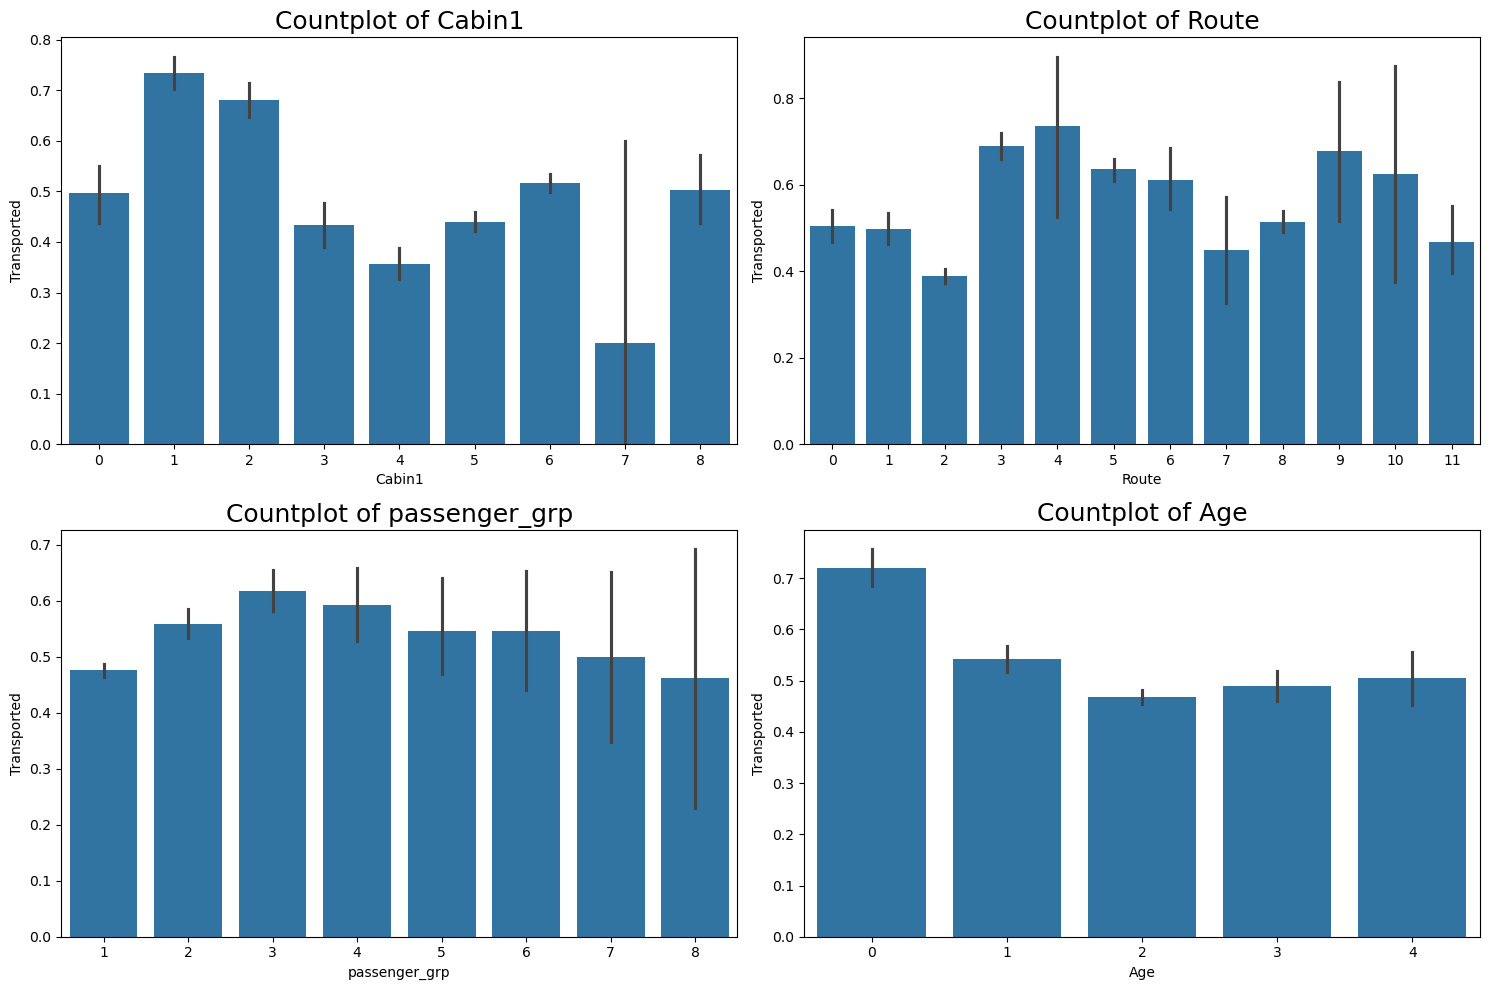

In [46]:
#피처별 생존율 그래프
fig, axes = plt.subplots(2,2, figsize=(15,10))     
cols = ['Cabin1', 'Route', 'passenger_grp', 'Age']

for ax, col in zip(axes.flatten(), cols):
    sns.barplot(x=col, y='Transported', data=train, ax=ax)
    ax.set_title(f'Countplot of {col}', fontdict={'fontsize':18})
plt.tight_layout()
plt.show()

<Axes: >

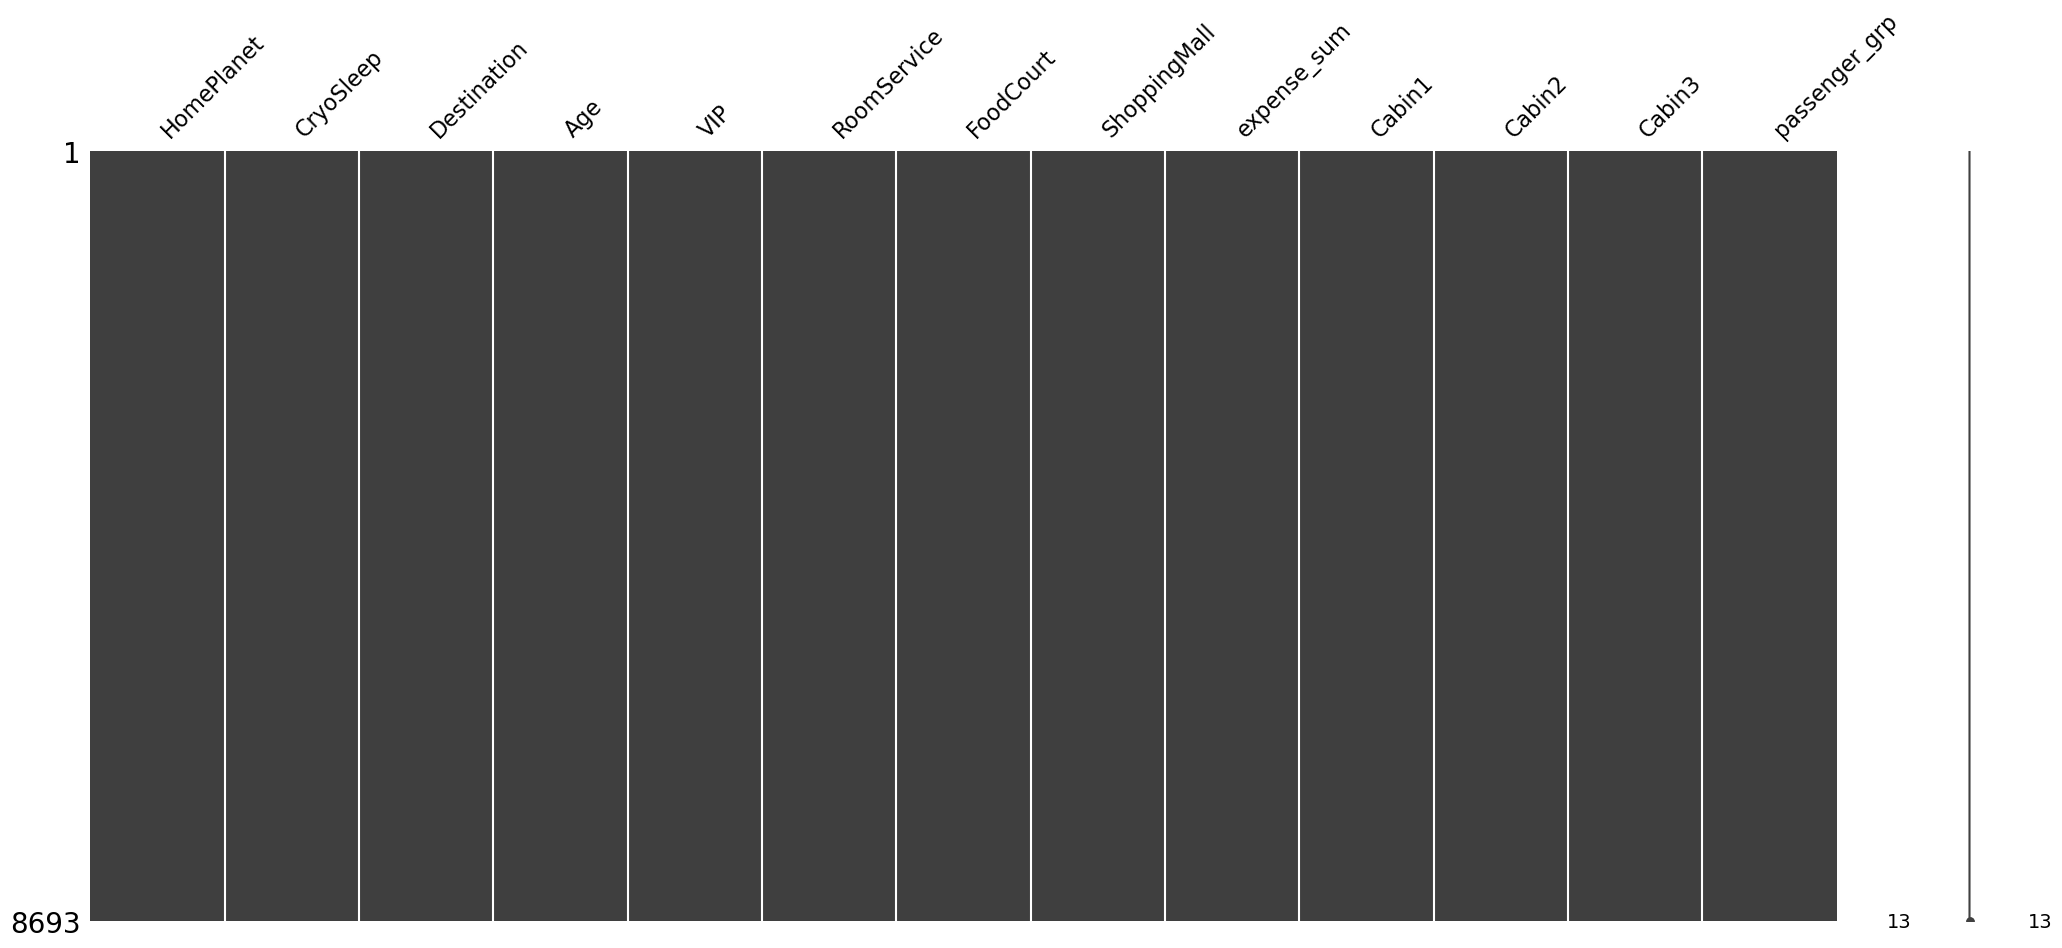

In [89]:
msno.matrix(train)

In [89]:
cor = train.corrwith(train['Transported']).sort_values(ascending=False)
print(cor)

Transported        1.000000
CryoSleep          0.460132
HomePlanet         0.107755
Cabin3             0.093319
Route              0.069466
passenger_grp      0.066390
Active_No_Spend    0.056491
FoodCourt          0.045583
VIP               -0.037261
Age               -0.093032
Destination       -0.108152
Cabin1            -0.109925
expense_sum       -0.199514
RoomService       -0.241124
dtype: float64


Text(0.5, 1.0, 'Survival by HomePlanet')

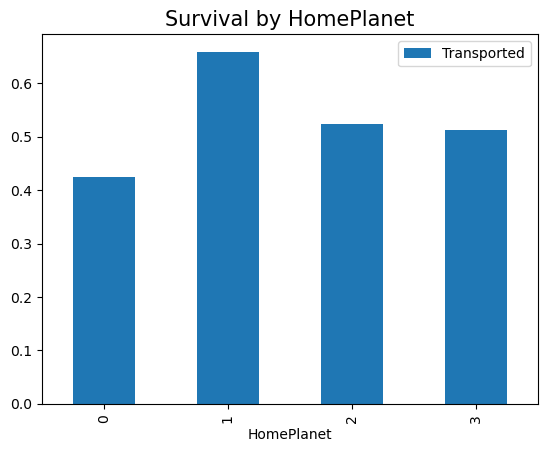

In [59]:
sur = train[['HomePlanet', 'Transported']].groupby(['HomePlanet']).mean().plot.bar()
sur.set_title('Survival by HomePlanet', size=15)

7. 학습 모델 함수 정의
- KNN, GBoost, XGBoost, RandomForest Classfier 모델들을 앙상블로 결합 사용

In [90]:
y = train['Transported']
del train['Transported']

y = y.astype(int)

In [93]:
from sklearn.model_selection import train_test_split
y = y.astype(int)

X_tr, X_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.15, random_state=2020)


from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics 
from sklearn.metrics import accuracy_score

random_state = 2020


# LGBM 하이퍼파라미터 튜닝 (GridSearchCV + 조기종료) 
lgbm_base = lgb.LGBMClassifier(n_estimators=1000, random_state=2020, verbosity=-1)

param_grid_lgbm = {
    'learning_rate': [0.09, 0.06, 0.03],
    'max_depth': [4, 5, 7],
    'num_leaves': [20, 25, 30],
    'min_child_samples': [20, 30, 40]
}

grid_lgbm = GridSearchCV(lgbm_base, param_grid_lgbm, cv=3, scoring='accuracy', n_jobs=-1)
grid_lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_vld, y_vld)],
    eval_metric='binary_logloss', # 로스 함수 지정
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), 
        lgb.log_evaluation(period=0)
    ]
)

# 최적의 lgbm 모델 추출
lgbm_best = grid_lgbm.best_estimator_
print(f"LGBM 최적 파라미터: {grid_lgbm.best_params_}")


xgboost_best = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    # gamma=0.1,
    random_state=2020,
    enable_categorical=True
)

# 최종 Voting 모델 재구성 
knn = KNeighborsClassifier(n_neighbors=5)
gboost = GradientBoostingClassifier(random_state=2020)
rdforest = RandomForestClassifier(random_state=2020)

weights = [0.7, 1.2, 1.5, 1.2, 0.9]
voting_weighted = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('gboost', gboost),
        ('xgboost', xgboost_best), # 튜닝된 모델
        ('lgbm', lgbm_best),       # 튜닝된 모델
        ('rdforest', rdforest)
    ],
    voting='soft',   # 확률 기반 가중 합산
    weights=weights  # 가중치 적용
)

voting_weighted.fit(X_tr, y_tr)

# train_acc = accuracy_score(y_tr, xgboost_best.predict(X_tr))
# val_acc = accuracy_score(y_vld, xgboost_best.predict(X_vld))
# print(f"Train Acc: {train_acc:.4f} / Val Acc: {val_acc:.4f}")

voting = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('gboost', gboost),
        ('xgboost', xgboost_best), # 튜닝된 모델
        ('lgbm', lgbm_best),       # 튜닝된 모델
        ('rdforest', rdforest)
    ],
    voting='soft'
)

voting.fit(X_tr, y_tr)

# prediction_vld = voting.predict(X_vld)
prediction_vld = voting_weighted.predict(X_vld)

print(f"Voting 검증 정확도: {accuracy_score(y_vld, prediction_vld):.4f}")



Early stopping, best iteration is:
[86]	valid_0's binary_logloss: 0.460814
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[104]	valid_0's binary_logloss: 0.453194
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[133]	valid_0's binary_logloss: 0.458278
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[126]	valid_0's binary_logloss: 0.458476
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[117]	valid_0's binary_logloss: 0.455032
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[136]	valid_0's binary_logloss: 0.457464
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's binary_logloss: 0.458293
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[123]	

In [94]:
# 전체 데이터로 다시 학습 (이미 튜닝된 파라미터 사용)
X_all_train = train.drop(['Transported'], axis=1, errors='ignore')
voting.fit(X_all_train, y)

test_features = test.drop(['Transported'], axis=1, errors='ignore')
final_prediction = voting.predict(test_features).astype(bool)


8. 제출용 파일 작성

In [95]:
submission = pd.DataFrame({
    'PassengerId': test_id.reset_index(drop=True),
    'Transported': final_prediction.astype(bool)
})

submission.to_csv('~/work/kaggle_kakr_housing/space_titanic/Titanic_submission_v09.csv', index=False)
print(submission.head())

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False

Early stopping, best iteration is:
[241]	valid_0's binary_logloss: 0.457941

Early stopping, best iteration is:
[216]	valid_0's binary_logloss: 0.459073
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[400]	valid_0's binary_logloss: 0.450399
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[289]	valid_0's binary_logloss: 0.454076
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[192]	valid_0's binary_logloss: 0.458763
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[313]	valid_0's binary_logloss: 0.454625
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[373]	valid_0's binary_logloss: 0.456256

파일 제출 이후 화면 캡쳐

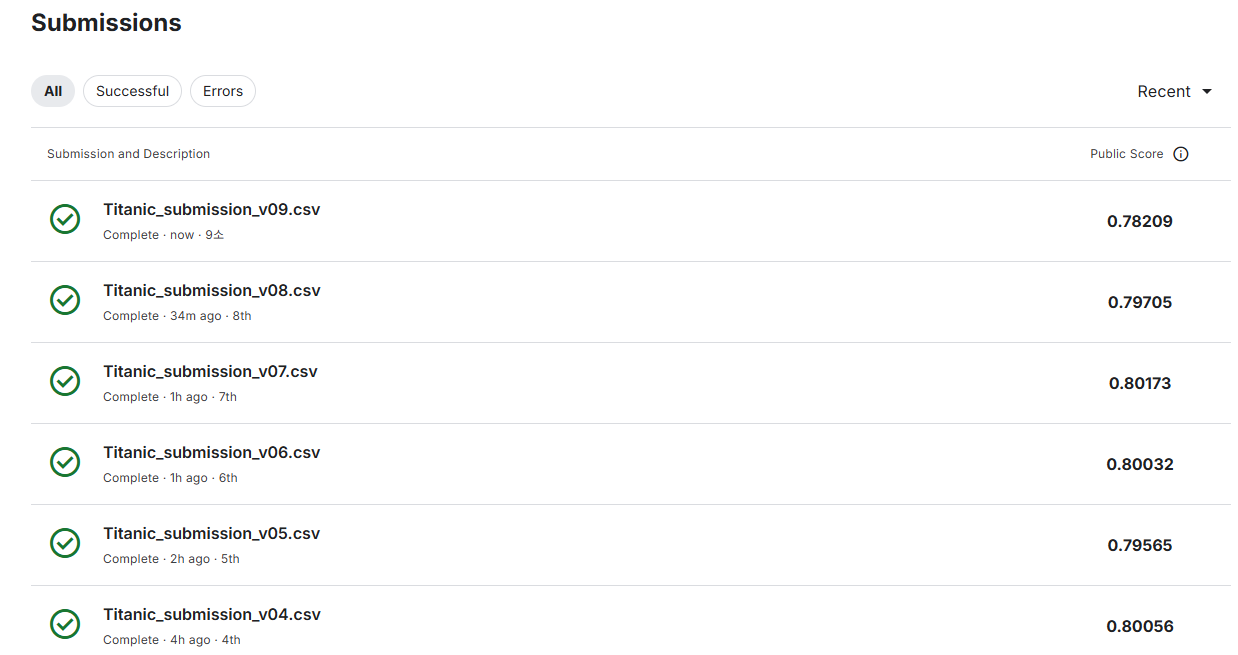
